In [129]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import math

In [130]:
FILE = '../data/raw_data/suggestions.csv'
"""
raw df has continous time series data for each user, no gap between days.
1 sugg.select.utime is Nan: invalid
Number of unique users: 37
"""
df = pd.read_csv(FILE)

df.dropna(subset=['sugg.select.utime'], inplace=True)
df['datetime'] = pd.to_datetime(df['sugg.select.utime'])
df['date'] = df['datetime'].dt.date     

users = df['user.index'].unique()
n_users = len(users)
ncols = 6
nrows = math.ceil(n_users / ncols)


/var/folders/ck/63g66f6935lgl8mlzt8bpztr0000gn/T/ipykernel_84616/3223493120.py:7: DtypeWarning: Columns (0: send.active, 1: send.sedentary, 2: dec.windspeed, 3: dec.precipitation.chance, 4: response.windspeed, 5: response.precipitation.chance) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(FILE)


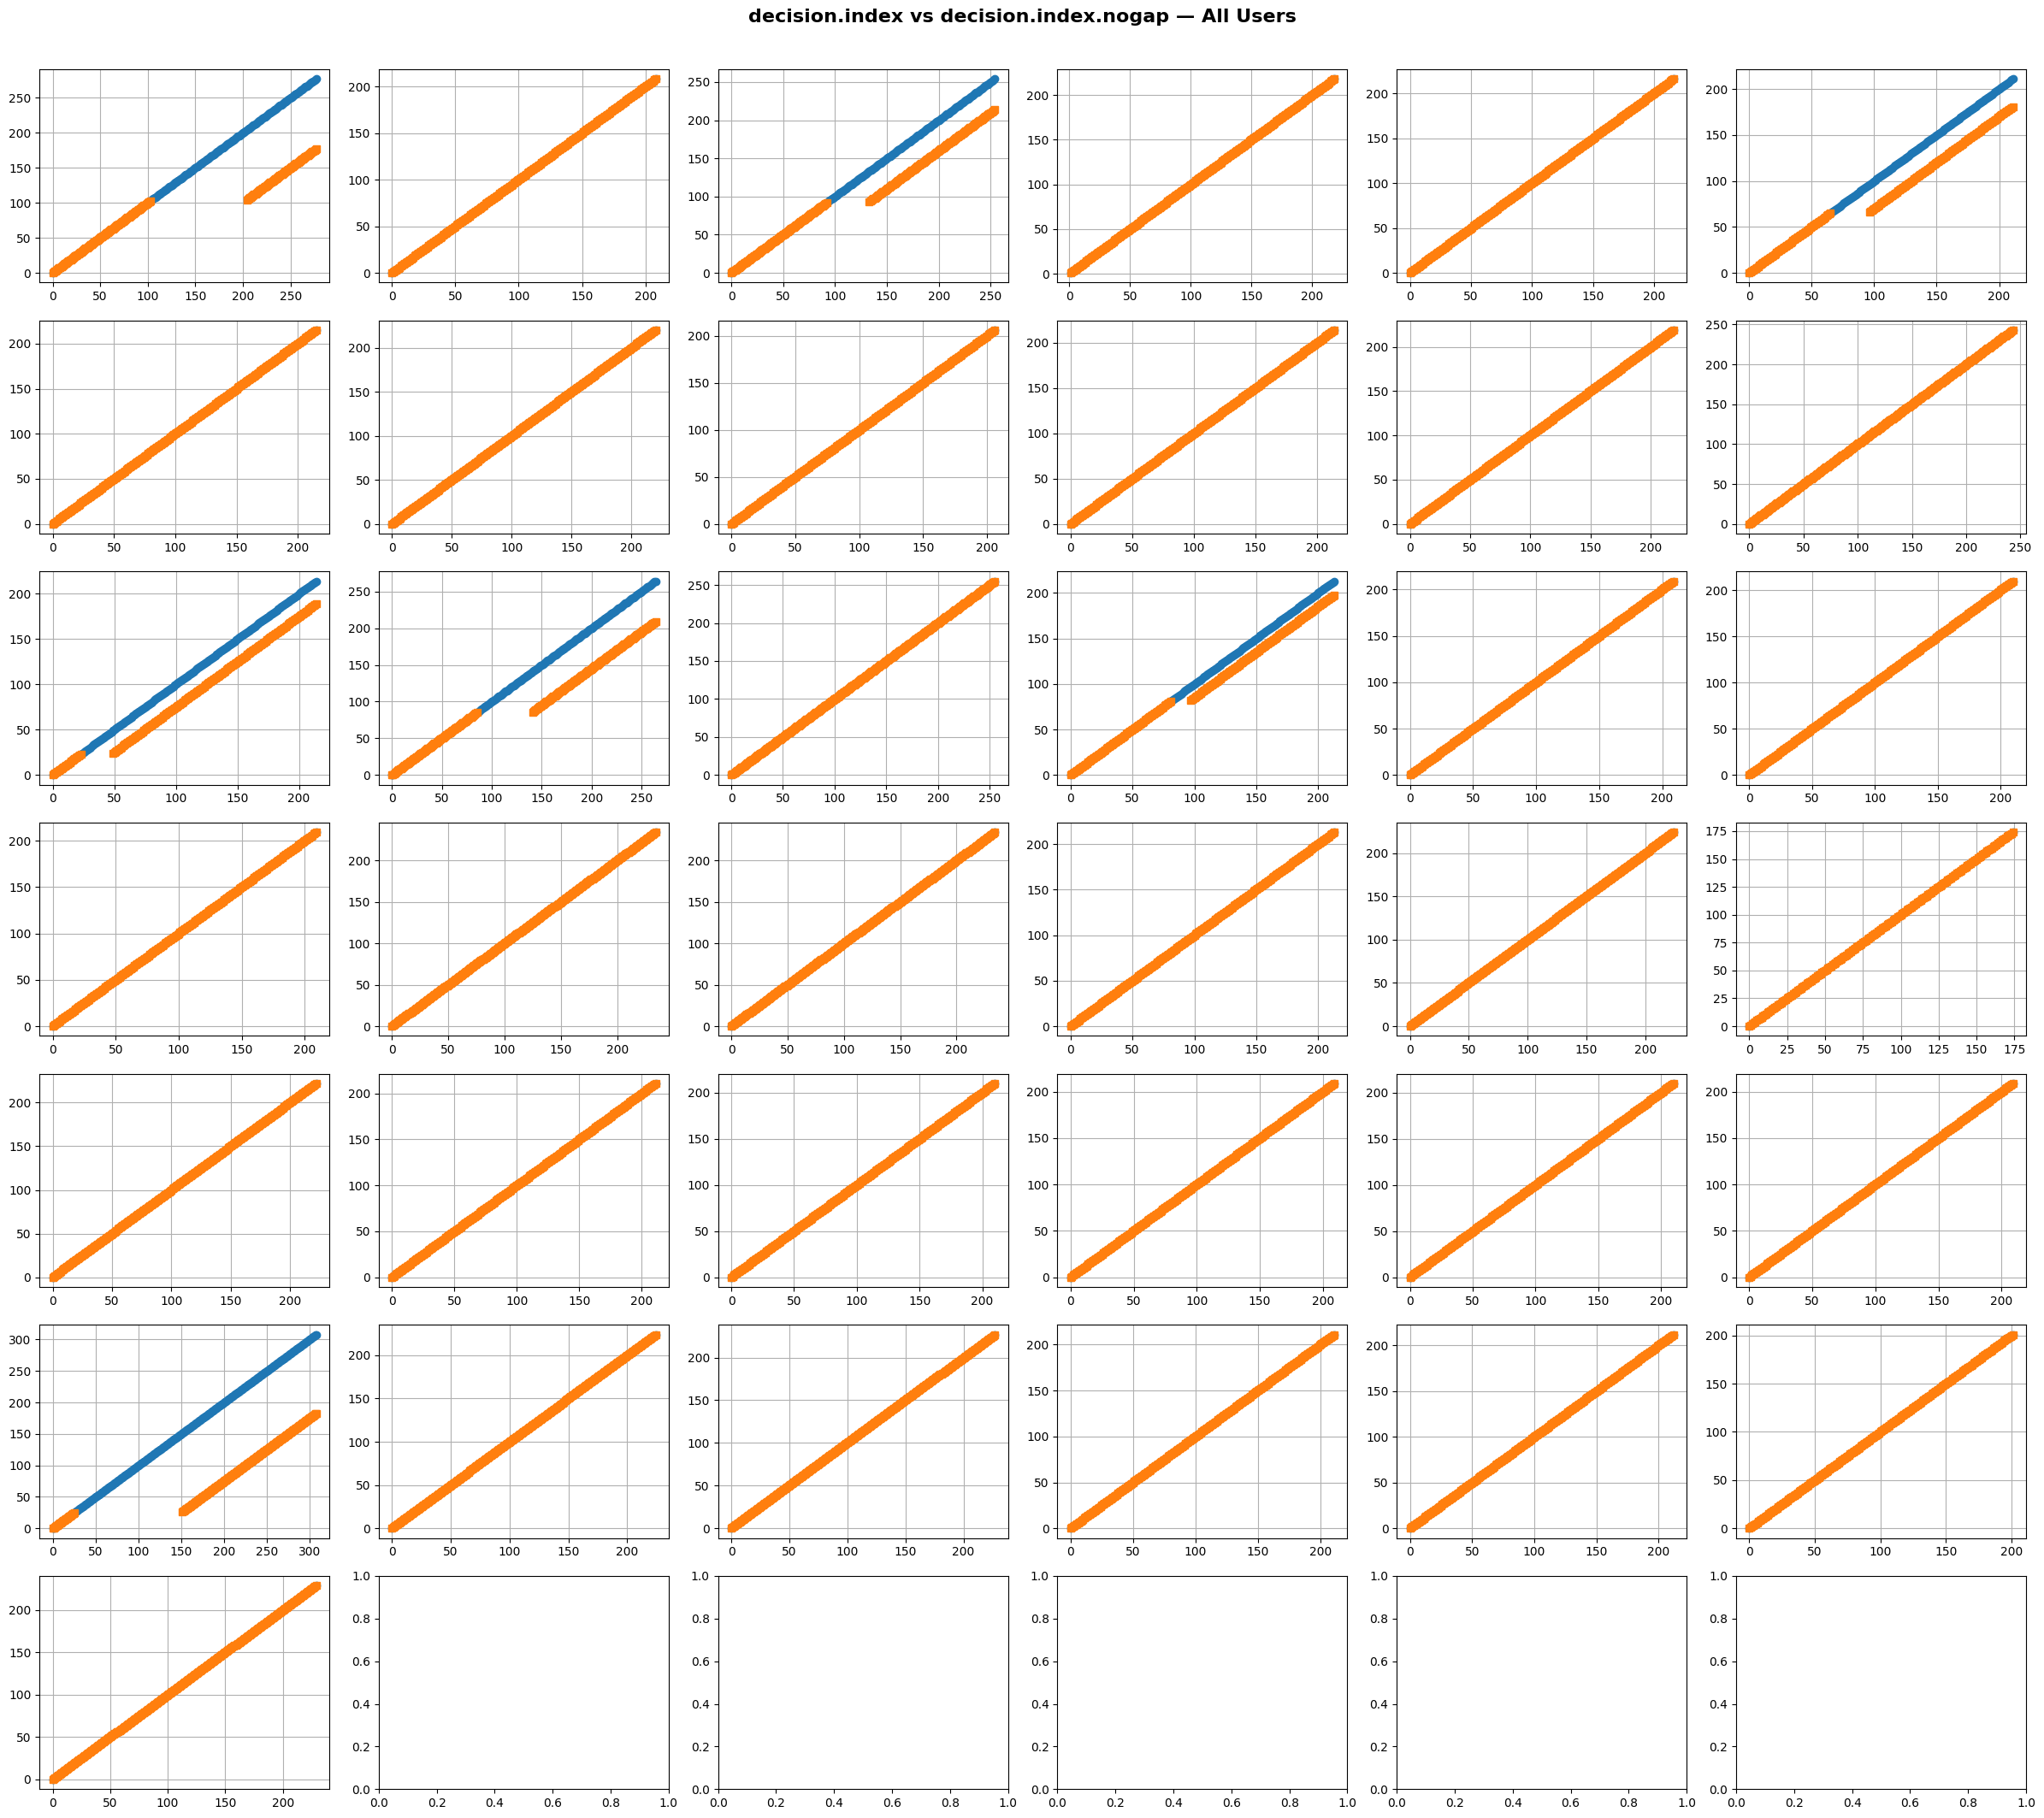

In [131]:
fig1, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*3))
fig1.suptitle('decision.index vs decision.index.nogap — All Users', fontsize=16, fontweight='bold', y=1.01)
axes_flat = axes.flatten()

for idx, user in enumerate(users):
    user_df = df[df['user.index'] == user]
    ax = axes_flat[idx]
    ax.plot(user_df['decision.index'], user_df['decision.index'], 
             label='decision.index', marker='o', linestyle='-', linewidth=2)
    ax.plot(user_df['decision.index'], user_df['decision.index.nogap'], 
             label='decision.index.nogap', marker='s', linestyle='--', linewidth=2)
    ax.grid(True)
fig1.tight_layout()
plt.show()
plt.close()

In [132]:
sdf = df.dropna(subset=['decision.index.nogap', 'sugg.select.utime'])
print(f"After dropping rows with NaN in 'decision.index.nogap', the number of rows is: {len(sdf)}")


After dropping rows with NaN in 'decision.index.nogap', the number of rows is: 7883


In [133]:
sdf = df.dropna(subset=['decision.index.nogap', 'sugg.select.utime'])
print(f"After dropping rows with NaN in 'decision.index.nogap', the number of rows is: {len(sdf)}")
print(sdf.isna().sum().to_string())

"""
647 returned.message == Nan: invalid
"""
sdf = sdf.dropna(subset=['returned.message', 'send.active'])
print(sdf['send'].unique())
print(f"After dropping rows with NaN in 'returned.message', the number of rows is: {len(sdf)}")
print(sdf.isna().sum().to_string())


After dropping rows with NaN in 'decision.index.nogap', the number of rows is: 7883
user.index                          0
decision.index                      0
decision.index.nogap                0
sugg.select.utime                   0
sugg.select.slot                    0
sugg.select.update                  0
sugg.tz                           647
sugg.gmtoff                         0
sugg.decision.utime                 0
sugg.decision.slot                647
sugg.context.utime                647
sugg.response.utime              4971
sugg.device.utime                2089
sugg.device.since                2089
interaction.count                4971
connect                             0
is.randomized                     647
snooze.status                     647
intransit                         647
avail                               0
send                              647
send.active                         1
send.sedentary                      1
is.prefetch                       647
reco

In [134]:
"""
when send.active == False and send.sedentary == False, returned.message is always 'donotnotify'
when send == False, returned.message is always 'donotnotify'
when returned.message == 'donotnotify', send == False
"""
print(sdf[(sdf['send.active'] == False) & (sdf['send.sedentary'] == False)]['returned.message'].unique())
print(sdf[(sdf['send'] == False)]['returned.message'].unique())
print(sdf['response'].unique())

print(sdf['recognized.activity'].unique())
print(sdf['recognized.activity.response'].unique())

"""
when returned.message is 'donotnotify', 
tag.indoor
tag.active                  
tag.indoor                  
tag.outdoor                 
tag.outdoor_snow      
are always NaN      
"""
print(sdf[sdf['tag.active'].isna()]['returned.message'].unique())
print(sdf[sdf['tag.indoor'].isna()]['returned.message'].unique())

<StringArray>
['donotnotify']
Length: 1, dtype: str
<StringArray>
['donotnotify']
Length: 1, dtype: str
<StringArray>
[                'good',                    nan,                  'bad',
          'no_response',  'snoozed_for_4_hours', 'snoozed_for_12_hours']
Length: 6, dtype: str
<StringArray>
['STILL', 'UNKNOWN', 'IN_VEHICLE', 'ON_FOOT', 'ON_BICYCLE',
 'AUGMENTED_VEHICLE']
Length: 6, dtype: str
<StringArray>
['STILL', nan, 'ON_FOOT', 'UNKNOWN', 'IN_VEHICLE', 'ON_BICYCLE']
Length: 6, dtype: str
<StringArray>
['donotnotify']
Length: 1, dtype: str
<StringArray>
['donotnotify']
Length: 1, dtype: str


In [135]:
print(sdf['response'].unique())

print(sdf['recognized.activity'].unique())
print(sdf['recognized.activity.response'].unique())

<StringArray>
[                'good',                    nan,                  'bad',
          'no_response',  'snoozed_for_4_hours', 'snoozed_for_12_hours']
Length: 6, dtype: str
<StringArray>
['STILL', 'UNKNOWN', 'IN_VEHICLE', 'ON_FOOT', 'ON_BICYCLE',
 'AUGMENTED_VEHICLE']
Length: 6, dtype: str
<StringArray>
['STILL', nan, 'ON_FOOT', 'UNKNOWN', 'IN_VEHICLE', 'ON_BICYCLE']
Length: 6, dtype: str


In [136]:
ddf = df.groupby(['user.index', 'date']).size().reset_index(name='num_decisions')
sddf = sdf.groupby(['user.index', 'date']).size().reset_index(name='num_decisions')

for idx, user in enumerate(users):
    user_ddf = ddf[ddf['user.index'] == user]
    user_sddf = sddf[sddf['user.index'] == user]
    expected = user_ddf['date'].nunique()
    actual = user_sddf['date'].nunique()
    if expected != actual:
        print(f"User {user} has {expected} unique dates in ddf but only {actual} unique dates in sddf.")

User 1 has 56 unique dates in ddf but only 36 unique dates in sddf.
User 3 has 52 unique dates in ddf but only 44 unique dates in sddf.
User 6 has 44 unique dates in ddf but only 39 unique dates in sddf.
User 13 has 44 unique dates in ddf but only 40 unique dates in sddf.
User 14 has 54 unique dates in ddf but only 43 unique dates in sddf.
User 16 has 44 unique dates in ddf but only 41 unique dates in sddf.
User 23 has 46 unique dates in ddf but only 45 unique dates in sddf.
User 28 has 43 unique dates in ddf but only 41 unique dates in sddf.
User 31 has 62 unique dates in ddf but only 38 unique dates in sddf.
User 33 has 46 unique dates in ddf but only 45 unique dates in sddf.


In [137]:
ddf = df.groupby(['user.index', 'date']).size().reset_index(name='num_decisions')
sddf = sdf.groupby(['user.index', 'date']).size().reset_index(name='num_decisions')

for idx, user in enumerate(users):
    user_ddf = ddf[ddf['user.index'] == user]
    user_sddf = sddf[sddf['user.index'] == user]
    expected = user_ddf['date'].nunique()
    actual = user_sddf['date'].nunique()
    if expected != actual:
        print(f"User {user} has {expected} unique dates in ddf but only {actual} unique dates in sddf.")

User 1 has 56 unique dates in ddf but only 36 unique dates in sddf.
User 3 has 52 unique dates in ddf but only 44 unique dates in sddf.
User 6 has 44 unique dates in ddf but only 39 unique dates in sddf.
User 13 has 44 unique dates in ddf but only 40 unique dates in sddf.
User 14 has 54 unique dates in ddf but only 43 unique dates in sddf.
User 16 has 44 unique dates in ddf but only 41 unique dates in sddf.
User 23 has 46 unique dates in ddf but only 45 unique dates in sddf.
User 28 has 43 unique dates in ddf but only 41 unique dates in sddf.
User 31 has 62 unique dates in ddf but only 38 unique dates in sddf.
User 33 has 46 unique dates in ddf but only 45 unique dates in sddf.


In [138]:
cols = ["dec.location.category"]

for col in cols:
    print(sdf[col].value_counts().to_string())

dec.location.category
home                                                                                                                        1764
work                                                                                                                        1058
university,point_of_interest,establishment                                                                                   556
store,point_of_interest,establishment                                                                                        541
park,point_of_interest,establishment                                                                                         402
electronics_store,store,point_of_interest,establishment                                                                      402
restaurant,food,point_of_interest,establishment                                                                              239
bakery,store,meal_takeaway,cafe,restaurant,food,point_of_interest,establish

In [139]:
col = ["dec.location.category"]
for user in users:
    print(f"----------------user{user}-------------------:")
    user_sdf = sdf[sdf['user.index'] == user]
    print(user_sdf["dec.location.category"].value_counts().to_string())

----------------user1-------------------:
dec.location.category
home                                                                                                                101
work                                                                                                                 32
bar,restaurant,food,point_of_interest,establishment                                                                   5
restaurant,food,point_of_interest,establishment                                                                       4
university,point_of_interest,establishment                                                                            4
store,point_of_interest,establishment                                                                                 3
furniture_store,hardware_store,general_contractor,home_goods_store,store,storage,point_of_interest,establishment      3
home_goods_store,store,point_of_interest,establishment                                          

In [140]:
def classify_location(cat):
    cat_lower = cat.lower()

    # 1. Home
    if cat_lower == 'home':
        return 'Home'

    # 2. Work
    if cat_lower == 'work':
        return 'Work'

    if cat_lower == 'unknown':
        return 'Unknown'

    if any(k in cat_lower for k in ['gym', 'bowling_alley', 'stadium']):
        return 'Sports & Fitness - Indoor High-Activity'

    if any(k in cat_lower for k in ['pharmacy', 'doctor', 'hospital', 'dentist',
                                      'beauty_salon', 'hair_care', 'spa']):
        return 'Healthcare & Personal Care - Indoor Low-Activity'

    if any(k in cat_lower for k in ['restaurant', 'cafe', 'bakery', 'meal_takeaway',
                                      'meal_delivery', 'bar']):
        return 'Food & Dining'

    if any(k in cat_lower for k in ['museum', 'art_gallery', 'casino', 'night_club']):
        return 'Leisure & Entertainment- Indoor Low-Activity'

    if any(k in cat_lower for k in ['park', 'campground']):
        return 'Parks & Recreation - Outdoor High-Activity'

    if any(k in cat_lower for k in ['gas_station', 'car_repair', 'car_dealer',
                                      'airport', 'parking']):
        return 'Auto & Transport - Outdoor Low-Activity'

    # if any(k in cat_lower for k in ['store', 'shopping_mall', 'department_store']):
    #     return 'Shopping/Retail'

    if any(k in cat_lower for k in ['university', 'school', 'library']):
        return 'University/School'

    if any(k in cat_lower for k in ['grocery_or_supermarket', 'convenience_store',
                                          'liquor_store']):
            return 'Grocery & Convenience Store'

    if 'electronics_store' in cat_lower:
        return 'Electronics Store'

    if any(k in cat_lower for k in ['clothing_store', 'shoe_store', 'jewelry_store']):
        return 'Clothing & Fashion Store'

    if any(k in cat_lower for k in ['home_goods_store', 'furniture_store', 'general_contractor']):
        return 'Home & Furniture Store'

    # if 'department_store' in cat_lower:
    #     return 'Department Store'
    #
    if any(k in cat_lower for k in ['book_store', 'pet_store', 'florist',
                                     'hardware_store', 'bicycle_store', 'movie_rental', 'painter',
                                    'insurance_agency', 'finance', 'locksmith', 'laundry', 'storage',
                                    'cemetery', 'department_store']):
        return 'Other Specialty Store'

    if any(k in cat_lower for k in ['food']):
            return 'Grocery & Convenience Store'

    if any(k in cat_lower for k in ['health']):
        return 'Healthcare & Personal Care - Indoor Low-Activity'

    if any(k in cat_lower for k in ['store']):
            return 'Just Store'

    return cat_lower


In [141]:
sdf['location_group'] = sdf['dec.location.category'].apply(classify_location)
print(sdf['location_group'].value_counts().to_string())



location_group
Home                                                1764
Work                                                1058
Food & Dining                                        755
University/School                                    753
Just Store                                           541
Parks & Recreation - Outdoor High-Activity           424
Electronics Store                                    410
Home & Furniture Store                               352
Healthcare & Personal Care - Indoor Low-Activity     297
Clothing & Fashion Store                             191
Grocery & Convenience Store                          180
Auto & Transport - Outdoor Low-Activity              175
Other Specialty Store                                138
Sports & Fitness - Indoor High-Activity              108
Unknown                                               80
Leisure & Entertainment- Indoor Low-Activity           9


In [142]:
weather_conditions = ['dec.weather.condition', 'dec.temperature']

'''
impute null: unknown
'''
sdf.loc[sdf['dec.weather.condition'].isnull() & sdf['response.weather.condition'].notnull(), 'dec.weather.condition'] = sdf['response.weather.condition']


'''
impute null & -1024.0: unknown
'''
sdf.loc[sdf['dec.temperature'].isnull() & sdf['response.temperature'].notnull(), 'dec.temperature'] = sdf['response.temperature']

print(sdf[sdf['dec.temperature'] < -100]['dec.temperature'].value_counts().to_string())

sdf.loc[sdf['dec.temperature'] < -100, 'dec.temperature'] = None


dec.temperature
-1024.0    33


In [153]:
# cols = ['user.index', 'decision.index.nogap', 'datetime', 'date', 'sugg.select.utime', 'sugg.select.slot', 'is.randomized', 'avail', 'send', 'send.active', 'send.sedentary', 'returned.message', 'sugg.response.utime', 'response', 'recognized.activity', 'location_group', 'dec.location.category', 'dec.weather.condition', 'dec.temperature', 'jbsteps10.zero', 'jbsteps30.zero', 'jbsteps40.zero', 'jbsteps60.zero', 'jbsteps90.zero', 'jbsteps120.zero', 'jbsteps30pre.zero', 'jbsteps40pre.zero', 'jbsteps60pre.zero']

sdf['jbsteps30'] = sdf['jbsteps30'].fillna(sdf['gfsteps30'])
sdf['jbsteps30pre'] = sdf['jbsteps30pre'].fillna(sdf['gfsteps30pre'])
#
# sdf['jbsteps30'] = sdf['jbsteps30'].fillna(sdf['jbsteps30.zero'])
# sdf['jbsteps30pre'] = sdf['jbsteps30pre'].fillna(sdf['jbsteps30pre.zero'])

# print(sdf.isnull().sum().to_string())

sdf = sdf.loc[sdf['jbsteps30'].notna() & sdf['jbsteps30pre'].notna()]

# print(sdf.isnull().sum().to_string())
cols = ['user.index', 'decision.index.nogap', 'datetime', 'date', 'sugg.select.utime', 'sugg.select.slot', 'is.randomized', 'avail', 'send', 'send.active', 'send.sedentary', 'returned.message', 'sugg.response.utime', 'response', 'recognized.activity', 'location_group', 'dec.location.category', 'dec.weather.condition', 'dec.temperature', 'jbsteps30', 'jbsteps30pre']

output = sdf[cols]
print(len(output))
print(output.isnull().sum().to_string())


output.to_csv('./output.csv', index=False)


6728
user.index                  0
decision.index.nogap        0
datetime                    0
date                        0
sugg.select.utime           0
sugg.select.slot            0
is.randomized               0
avail                       0
send                        0
send.active                 0
send.sedentary              0
returned.message            0
sugg.response.utime      4017
response                 4017
recognized.activity         0
location_group              0
dec.location.category       0
dec.weather.condition      30
dec.temperature           105
jbsteps30                   0
jbsteps30pre                0
